📊 FINAL MULTI-VARIABLE OPTIMIZATION:
   -> Algorithm: Stacked LSTM + Dropout
   -> Drivers: Historical Lags + Temperature + Rainfall + Holidays

Building the Upgraded Stacked LSTM...
Training Deep Learning Network...
Epoch 1/85


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1061/1061 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0197
Epoch 2/85
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0089
Epoch 3/85
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0080
Epoch 4/85
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0077
Epoch 5/85
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0076
Epoch 6/85
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0073
Epoch 7/85
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0072
Epoch 8/85
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0071
Epoch 9/85
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0070
Epoch 10/85
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0070
Epoch 11/85
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0070
Epoch 12/85
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0069
Epoch 13/85
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0069
Epoch 14/85
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0069
Epoch 15/85
1061/1061 ━━━━━━━━━━━━━━━━━━

/tmp/ipykernel_1104/4221943676.py:219: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

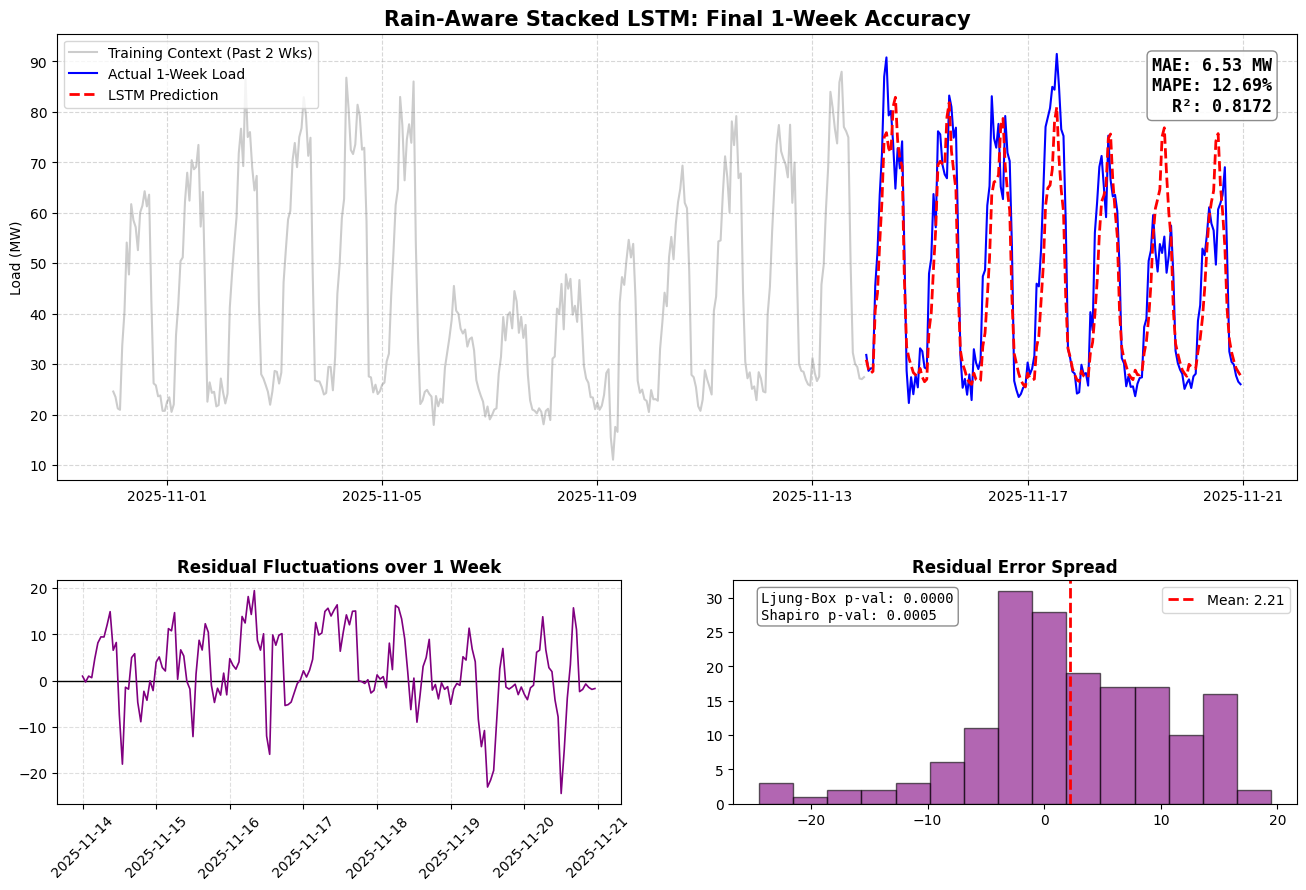

In [ ]:
# 0. AUTOMATIC SETUP
try:
    import holidays
except ModuleNotFoundError:

    !pip install holidays -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import holidays
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from google.colab import files

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# 1. Load the dataset
df = pd.read_excel('../data/Hourly_Data_220kV.xlsx')
df.columns = df.columns.str.strip()

# Auto-detect columns (Now looking for Rain as well)
date_col = [col for col in df.columns if 'date' in col.lower()][0]
time_col = [col for col in df.columns if 'time' in col.lower()][0]
load_col = [col for col in df.columns if 'load' in col.lower()][0]
temp_col = [col for col in df.columns if 'temp' in col.lower()][0]
# Look for a column that has 'rain' or 'precip' in its name
rain_col = [col for col in df.columns if 'rain' in col.lower() or 'precip' in col.lower()][0]

df['Datetime'] = pd.to_datetime(df[date_col].astype(str) + ' ' + df[time_col].astype(str))
df = df.set_index('Datetime').sort_index()

# 2. Extract and fill targets (Load, Temp, AND Rain)
target_series = pd.to_numeric(df[load_col], errors='coerce').resample('h').mean().ffill()
temp_series = pd.to_numeric(df[temp_col], errors='coerce').resample('h').mean().ffill()
rain_series = pd.to_numeric(df[rain_col], errors='coerce').resample('h').mean().ffill()

# 3. ADVANCED FEATURE ENGINEERING (Weather + Holidays)
df_clean = pd.DataFrame({
    'Load': target_series,
    'Temp': temp_series,
    'Rain': rain_series
})

df_clean['Hour_Norm'] = df_clean.index.hour / 23.0
df_clean['Day_Norm'] = df_clean.index.dayofweek / 6.0

# Generate Indian Public Holidays
india_holidays = holidays.IN(years=list(df_clean.index.year.unique()))

# Flag if it is Saturday (5), Sunday (6), or a public holiday
df_clean['Is_Holiday'] = df_clean.index.map(
    lambda x: 1.0 if (x.dayofweek >= 5 or x in india_holidays) else 0.0
)

# 4. SCALING
scaler_y = MinMaxScaler()
scaler_X = MinMaxScaler()

df_clean['Load_Scaled'] = scaler_y.fit_transform(df_clean[['Load']])
# Scale Temperature and Rain together
df_clean[['Temp_Scaled', 'Rain_Scaled']] = scaler_X.fit_transform(df_clean[['Temp', 'Rain']])

# 5. CONSTRUCT DATASET WITH NEW RAIN FACTOR
test_steps = 168
lookback_max = 168

features, targets, timestamps = [], [], []

for i in range(lookback_max, len(df_clean)):
    lag_24 = df_clean['Load_Scaled'].iloc[i - 24]
    lag_48 = df_clean['Load_Scaled'].iloc[i - 48]
    lag_168 = df_clean['Load_Scaled'].iloc[i - 168]

    curr_temp = df_clean['Temp_Scaled'].iloc[i]
    curr_rain = df_clean['Rain_Scaled'].iloc[i]  # <-- NEW RAINFALL MEMORY
    curr_hour = df_clean['Hour_Norm'].iloc[i]
    curr_day = df_clean['Day_Norm'].iloc[i]
    curr_hol = df_clean['Is_Holiday'].iloc[i]

    # Input vector now has 8 crucial features
    input_vector = [lag_24, lag_48, lag_168, curr_temp, curr_rain, curr_hour, curr_day, curr_hol]

    features.append(input_vector)
    targets.append(df_clean['Load_Scaled'].iloc[i])
    timestamps.append(df_clean.index[i])

X_all = np.array(features)
y_all = np.array(targets)
dates_all = pd.to_datetime(timestamps)

X_all = X_all.reshape((X_all.shape[0], 1, X_all.shape[1]))

X_train, y_train = X_all[:-test_steps], y_all[:-test_steps]
X_test, y_test = X_all[-test_steps:], y_all[-test_steps:]
test_dates = dates_all[-test_steps:]



# 6. UPGRADED LSTM ARCHITECTURE
print("\nBuilding the Upgraded Stacked LSTM...")
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(1, X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(32))
model.add(Dense(1))

model.compile(optimizer=Adam(learning_rate=0.0005), loss='mse')

print("Training Deep Learning Network...")
history = model.fit(X_train, y_train, epochs=85, batch_size=16, verbose=1, shuffle=False)


# 7. RECURSIVE INFERENCE
print("Executing Recursive Forecast...")
full_scaled_load = list(df_clean['Load_Scaled'].values)
forecast_scaled = []

# Fetch exogenous inputs (including Rain) for the blind test week
test_exog = df_clean[['Temp_Scaled', 'Rain_Scaled', 'Hour_Norm', 'Day_Norm', 'Is_Holiday']].iloc[-test_steps:].values

for step in range(test_steps):
    current_index = len(full_scaled_load) - test_steps + step

    l_24 = full_scaled_load[current_index - 24]
    l_48 = full_scaled_load[current_index - 48]
    l_168 = full_scaled_load[current_index - 168]

    exog_current = test_exog[step]

    # Rebuild the 8-feature array: [l24, l48, l168, Temp, Rain, Hour, Day, Holiday]
    x_input = np.array([[l_24, l_48, l_168, exog_current[0], exog_current[1], exog_current[2], exog_current[3], exog_current[4]]])
    x_input = x_input.reshape((1, 1, 8))

    pred_scaled = model(x_input, training=False).numpy()[0][0]

    forecast_scaled.append(pred_scaled)
    full_scaled_load[current_index] = pred_scaled

# 8. INVERSE TRANSFORM RESULTS
predictions_mw = scaler_y.inverse_transform(np.array(forecast_scaled).reshape(-1, 1)).flatten()
actual_mw = df_clean['Load'].iloc[-test_steps:].values

predictions_series = pd.Series(predictions_mw, index=test_dates)
actual_series = pd.Series(actual_mw, index=test_dates)

# ==========================================
# 9. METRICS, P-VALUES & DASHBOARD
# ==========================================
mae = mean_absolute_error(actual_series, predictions_series)
rmse = np.sqrt(mean_squared_error(actual_series, predictions_series))
mape = mean_absolute_percentage_error(actual_series, predictions_series) * 100
r2 = r2_score(actual_series, predictions_series)

residuals = actual_series - predictions_series
mean_residual = residuals.mean()

lb_pvalue = acorr_ljungbox(residuals, lags=[24], return_df=True)['lb_pvalue'].values[0]
shapiro_pvalue = stats.shapiro(residuals)[1]


print(f"MAE:  {mae:.2f} MW")
print(f"RMSE: {rmse:.2f} MW")
print(f"MAPE: {mape:.2f} %")
print(f"R²:   {r2:.4f}")
print("\n" + "="*40)
print(" RESIDUAL DIAGNOSTICS")

print(f"Mean Error:         {mean_residual:.4f} MW")
print(f"Ljung-Box P-Value:  {lb_pvalue:.4f}")
print(f"Shapiro P-Value:    {shapiro_pvalue:.4f}")
print("="*40 + "\n")

# Dashboard Plotting
fig = plt.figure(figsize=(16, 10))
grid = plt.GridSpec(2, 2, height_ratios=[2, 1], wspace=0.2, hspace=0.3)

ax1 = fig.add_subplot(grid[0, :])
train_plot_context = df_clean['Load'].iloc[-test_steps - 336 : -test_steps]
ax1.plot(train_plot_context.index, train_plot_context, label='Training Context (Past 2 Wks)', color='gray', alpha=0.4)
ax1.plot(actual_series.index, actual_series, label='Actual 1-Week Load', color='blue', linewidth=1.5)
ax1.plot(predictions_series.index, predictions_series, label='LSTM Prediction', color='red', linestyle='--', linewidth=2)
ax1.set_title('Rain-Aware Stacked LSTM: Final 1-Week Accuracy', fontsize=15, fontweight='bold')
ax1.set_ylabel('Load (MW)')
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.5)

metrics_text = f"MAE: {mae:.2f} MW\nMAPE: {mape:.2f}%\nR²: {r2:.4f}"
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
ax1.text(0.98, 0.95, metrics_text, transform=ax1.transAxes, fontsize=12,
        verticalalignment='top', horizontalalignment='right', bbox=props, family='monospace', fontweight='bold')

ax2 = fig.add_subplot(grid[1, 0])
ax2.axhline(0, color='black', linewidth=1)
ax2.plot(residuals.index, residuals, color='purple', linewidth=1.2)
ax2.set_title('Residual Fluctuations over 1 Week', fontsize=12, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=45)

ax3 = fig.add_subplot(grid[1, 1])
ax3.hist(residuals, bins=15, color='purple', alpha=0.6, edgecolor='black')
ax3.axvline(mean_residual, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_residual:.2f}')
ax3.set_title('Residual Error Spread', fontsize=12, fontweight='bold')
ax3.legend()

pval_text = f"Ljung-Box p-val: {lb_pvalue:.4f}\nShapiro p-val: {shapiro_pvalue:.4f}"
ax3.text(0.05, 0.95, pval_text, transform=ax3.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='left', bbox=props, family='monospace')

plt.tight_layout()
image_filename = 'Rain_Aware_LSTM_Dashboard.png'
plt.savefig(image_filename, dpi=300, bbox_inches='tight')
files.download(image_filename)
plt.show()